In [ ]:
import os
import re
import glob
import math
import pickle
import numpy as np
import scipy.io as sio
import scipy.signal as signal
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import hilbert, welch
from utils import bandpassfilter

## Project 2D position to 1D postion

## using method from paper  Wang, M., Foster, D. J., & Pfeiffer, B. E. (2020). Alternating sequences of future and past behavior encoded within hippocampal theta oscillations. Science, 370(6513), 247-250

In [ ]:
def posterior2d_to_relative1d(posterior_cyc, pos_cyc, movedir_cyc,
                             state_idx=1, s_range=(-60, 60), ds=2.0,
                             normalize_each_time=True):
    """
    posterior_cyc: xarray.DataArray with dims ('time','state','x_position','y_position')
    pos_cyc: (Nc,2) true position in same coordinate system as x_position/y_position
    movedir_cyc: (Nc,) heading angle in radians (assumed: theta=0 along +x, CCW positive)
    state_idx: choose which 'state' slice to use
    s_range: relative location range (cm), e.g. (-60,60)
    ds: bin size (cm)
    returns:
        s_centers: (Nb,)
        rel1d: (Nc,Nb)  each time bin a 1D posterior over s
    """

    # coords
    x = np.asarray(posterior_cyc.coords["x_position"].values, float)
    y = np.asarray(posterior_cyc.coords["y_position"].values, float)

    # grid of positions (cell centers)
    X, Y = np.meshgrid(x, y, indexing="ij")  # shape (Nx,Ny)
    Xf = X.ravel()
    Yf = Y.ravel()

    s_min, s_max = s_range
    edges = np.arange(s_min, s_max + ds, ds)
    s_centers = (edges[:-1] + edges[1:]) / 2
    nb = len(s_centers)

    Nc = posterior_cyc.sizes["time"]
    rel1d = np.full((Nc, nb), np.nan, dtype=float)

    for i in range(Nc):
        # 2D posterior at this time
        P = posterior_cyc.isel(time=i, state=state_idx).values  # (Nx,Ny)
        P = np.asarray(P, float).ravel()
        P[~np.isfinite(P)] = 0.0

        # shift to animal-centered coordinates
        px, py = float(pos_cyc[i, 0]), float(pos_cyc[i, 1])
        dx = Xf - px
        dy = Yf - py

        # project onto heading direction => relative location s (ahead/behind)
        th = float(movedir_cyc[i])
        # ahead distance along heading vector u=(cos th, sin th)
        s = dx * np.cos(th) + dy * np.sin(th)

        # bin P by s
        bin_id = np.floor((s - s_min) / ds).astype(int)
        valid = (bin_id >= 0) & (bin_id < nb)

        sums = np.bincount(bin_id[valid], weights=P[valid], minlength=nb).astype(float)

        if normalize_each_time:
            tot = sums.sum()
            if tot > 0:
                sums /= tot

        rel1d[i, :] = sums

    return s_centers, rel1d


## Plot function

In [9]:

def plot_relLoc_vs_theta_heatmap(
    theta_cycles_day,
    bin_deg=20,
    s_key="rel_s_centers",
    post_key="rel_posterior_1d",
    phase_key="phase_deg",
    title=None,
    vmin=None,
    vmax=None,
    ylim=(-20, 20),
    cmap="jet",
    ax=None,
    add_colorbar=True,
    cbar_kwargs=None,
    shift_deg=0
):
    if 360 % bin_deg != 0:
        raise ValueError("bin_deg must divide 360 exactly")

    phases_list = []
    post_list = []
    s_centers = None

    for cyc in theta_cycles_day:
        if not all(k in cyc for k in [phase_key, post_key, s_key]):
            continue

        ph = np.asarray(cyc[phase_key], dtype=float)
        P1 = np.asarray(cyc[post_key], dtype=float)
        centers = np.asarray(cyc[s_key], dtype=float)

        if P1.ndim != 2 or ph.ndim != 1 or len(ph) != P1.shape[0]:
            continue

        if len(centers) != P1.shape[1]:
            continue

        if s_centers is None:
            s_centers = centers
        elif centers.shape != s_centers.shape or not np.allclose(centers, s_centers):
            continue

        keep = np.isfinite(ph) & np.all(np.isfinite(P1), axis=1)
        ph = ph[keep] % 360
        P1 = P1[keep]

        if ph.size == 0:
            continue

        if shift_deg is not None:
            ph = (ph - shift_deg) % 360

        phases_list.append(ph)
        post_list.append(P1)

    if not phases_list:
        return None

    phases = np.concatenate(phases_list)
    post1d = np.vstack(post_list)

    nb = 360 // bin_deg
    bin_id = np.floor(phases / bin_deg).astype(int)
    H = np.zeros((nb, post1d.shape[1]), dtype=float)
    C = np.zeros(nb, dtype=int)

    for b in range(nb):
        idx = bin_id == b
        C[b] = np.sum(idx)

        if C[b] == 0:
            continue

        row = np.nansum(post1d[idx], axis=0)
        row[row < 0] = 0

        total = row.sum()

        if total > 0:
            H[b] = row / total

    H2 = np.vstack([H, H])
    C2 = np.concatenate([C, C])
    Z = H2.T

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4.6), dpi=140)

    im = ax.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=[0, 720, s_centers[0], s_centers[-1]],
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        interpolation="bilinear"
    )

    ax.set_xlim(0, 720)
    ax.set_ylim(ylim)
    ax.set_xticks(np.arange(0, 721, 120))
    ax.set_xlabel("Theta phase (°)")
    ax.set_ylabel("Relative location (cm)")

    if title is not None:
        ax.set_title(title, fontsize=9)

    if add_colorbar:
        if cbar_kwargs is None:
            cbar_kwargs = dict(pad=0.02, fraction=0.03, aspect=30, shrink=0.95)

        cbar = plt.colorbar(im, ax=ax, **cbar_kwargs)
        cbar.ax.tick_params(labelsize=6)

    return {
        "s_centers": s_centers,
        "H": H,
        "H2": H2,
        "C": C,
        "C2": C2,
        "im": im
    }


def plot_one_animal_all_days_720(
    theta_cycles,
    animal,
    env="R",
    days=None,
    ncols=5,
    bin_deg=20,
    ylim=(-20, 20),
    cmap="jet",
    savepath=None,
    cell_w=3.2,
    cell_h=4.5,
    cbar_kwargs=None,
    method="spike",
    shift_deg=0
):
    cycles = [
        c for c in theta_cycles
        if c.get("animal") == animal
        and ("env" not in c or c.get("env") == env)
        and ("method" not in c or c.get("method") == method)
    ]

    all_days = sorted({int(c["day"]) for c in cycles})

    if days is None:
        days = all_days
    else:
        days = [int(d) for d in days]

    if not days:
        return None

    nrows = math.ceil(len(days) / ncols)

    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * cell_w, nrows * cell_h),
        dpi=140,
        sharex=True,
        sharey=True
    )

    axs = np.atleast_1d(axs).ravel()

    cycles_by_day = {}

    for cyc in cycles:
        day = int(cyc["day"])
        cycles_by_day.setdefault(day, []).append(cyc)

    plotted = 0

    for k, day in enumerate(days):
        ax = axs[k]
        day_cycles = cycles_by_day.get(day, [])

        out = plot_relLoc_vs_theta_heatmap(
            day_cycles,
            bin_deg=bin_deg,
            ylim=ylim,
            cmap=cmap,
            title=f"{animal} | {env} | Day {day}",
            ax=ax,
            add_colorbar=True,
            cbar_kwargs=cbar_kwargs,
            shift_deg=shift_deg
        )

        if out is None:
            ax.axis("off")
            continue

        plotted += 1
        ax.set_title(
            f"{animal} | {env} | Day {day}  cycles={len(day_cycles)}",
            fontsize=9
        )

    for ax in axs[len(days):]:
        ax.axis("off")

    fig.suptitle(
        f"{animal} | {env} | Relative loc vs theta phase (0–720)_{method}, bin={bin_deg}°",
        y=0.995,
        fontsize=12
    )

    fig.subplots_adjust(wspace=0.55, hspace=0.35, top=0.93)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if savepath is not None:
        fig.savefig(savepath, dpi=200)
        plt.close(fig)
    else:
        plt.show()

    print(f"Plotted {plotted}/{len(days)} days for {animal} ({env}).")

    return fig

## Help function

In [ ]:
def assign_stage(animal, day):
    early, late = mergeDays[animal]
    return "early" if day in early else "late" if day in late else None


def detect_days(filename):
    base = os.path.splitext(os.path.basename(filename))[0]
    match = re.search(r"Day(\d+)toDay(\d+)", base)

    if match:
        start, end = map(int, match.groups())
        return list(range(start, end + 1))

    data = sio.loadmat(filename, squeeze_me=True, struct_as_record=False)
    return list(range(1, len(data["data"].trials) + 1))


def compute_fs(timestamps):
    dt = np.diff(np.asarray(timestamps, dtype=float))
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return 1.0 / np.mean(dt) if dt.size else np.nan


def welch_psd(x, fs):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if x.size < 10 or not np.isfinite(fs) or fs <= 0:
        return None, None

    return welch(x, fs=fs, nperseg=min(4096, x.size))


def estimate_theta_band(x, fs, search_band=THETA_SEARCH_BAND, half_width=THETA_HALF_WIDTH):
    freqs, psd = welch_psd(x, fs)
    lo, hi = search_band
    peak = np.nan

    if freqs is not None:
        mask = (freqs >= lo) & (freqs <= hi)
        if np.any(mask):
            peak = float(freqs[mask][np.nanargmax(psd[mask])])

    if np.isfinite(peak):
        return peak, max(1.0, peak - half_width), min(30.0, peak + half_width)

    return peak, lo, hi


def keep_theta_cycle(t, lo_hz=THETA_SEARCH_BAND[0], hi_hz=THETA_SEARCH_BAND[1], margin=0.5):
    if len(t) < 2:
        return False

    duration = float(t[-1] - t[0])
    return 1.0 / (hi_hz + margin) <= duration <= 1.0 / (lo_hz - margin)


## Plot theta sequence

In [ ]:

SAVE_DIR = r"C:\VRresults"
DECODING_ROOT = r"Z:\decoding-ca1mec"

ENV = "VR"
CELLTYPE = "CA1MEC"


SPEED_THRESHOLD = 4.0
UPSAMPLING_SCALE = 4
MIN_RUNNING_DURATION = 1.0
MAX_ANGLE_STD = np.pi / 3

THETA_SEARCH_BAND = (6.0, 12.0)
THETA_HALF_WIDTH = 2.0

STATE_IDX = 0
S_RANGE = (-60, 60)
DS = 2.0

PHASE_SHIFT_DEG = 0
HEATMAP_BIN_DEG = 20
HEATMAP_YLIM = (-20, 20)

os.makedirs(SAVE_DIR, exist_ok=True)

animal_files = {
    "m11": [r"C:\decode\m11_Day1toDay8.mat", r"C:\decode\m11_Day9toDay15.mat"],
    "m18": [r"C:\decode\m18_alldays.mat"],
    "m20": [r"C:\decode\m20_alldays.mat"],
    "m29": [r"C:\decode\m29_alldays.mat"],
    "m48": [r"C:\decode\m48_alldays.mat"],
    "m57": [r"C:\decode\m57_alldays.mat"],
}

mergeDays = {
    "m11": [range(1, 8), range(8, 16)],
    "m12": [range(1, 6), range(6, 11)],
    "m18": [range(1, 3), range(3, 6)],
    "m20": [range(1, 6), range(6, 11)],
    "m22": [range(1, 6), range(6, 12)],
    "m29": [range(1, 2), range(2, 4)],
    "m48": [range(1, 10), range(10, 19)],
    "m57": [range(1, 9), range(9, 17)],
}



def day_cycle_path(animal, env, celltype, day):
    return os.path.join(SAVE_DIR, f"{animal}_{env}_theta_cycles_spike_Day{day:02d}.pkl")


def save_day_cycles(animal, env, celltype, day, new_cycles):
    path = day_cycle_path(animal, env, celltype, day)

    with open(path, "wb") as f:
        pickle.dump(new_cycles, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"Saved {len(new_cycles)} cycles -> {path}")


def load_theta_cycles_all_days(save_dir, animal, env, celltype):
    pattern = os.path.join(save_dir, f"{animal}_{env}_theta_cycles_{celltype}_spike_Day*.pkl")
    all_cycles = []

    for path in sorted(glob.glob(pattern)):
        with open(path, "rb") as f:
            cycles = pickle.load(f)
        if isinstance(cycles, list):
            all_cycles.extend(cycles)

    print(f"Loaded {len(all_cycles)} cycles for {animal}")
    return all_cycles


# Spike pipeline
def build_spike_cycles(
    animal,
    day,
    stage,
    env,
    celltype,
    periods,
    timestamps,
    t_run,
    pos_run,
    movedir_run,
    SpikeArray,
    is_running,
    posterior_run
):
    summed_spikes = np.nansum(SpikeArray, axis=0)
    summed_spikes_run = summed_spikes[is_running]

    fs = compute_fs(timestamps)
    peak, bp_lo, bp_hi = estimate_theta_band(summed_spikes_run, fs)

    filtered = bandpassfilter(summed_spikes, lowcut=bp_lo, highcut=bp_hi, fs=fs)
    filtered_run = filtered[is_running]

    phase = np.mod(np.angle(hilbert(filtered)), 2 * np.pi)
    phase_run = phase[is_running]

    cycles = []

    for start_time, end_time in periods:
        mask = (t_run >= start_time) & (t_run <= end_time)

        if np.sum(mask) < 10:
            continue

        time_block = t_run[mask]
        pos_block = pos_run[mask]
        movedir_block = movedir_run[mask]
        phase_block = phase_run[mask]
        spike_block = summed_spikes_run[mask]
        lfp_block = filtered_run[mask]
        posterior_block = posterior_run.isel(time=mask)

        troughs = signal.find_peaks(-lfp_block)[0]

        if len(troughs) < 2:
            continue

        for j in range(len(troughs) - 1):
            a, b = troughs[j], troughs[j + 1]
            t_cyc = time_block[a:b]

            if not keep_theta_cycle(t_cyc):
                continue

            pos_cyc = pos_block[a:b]
            phase_cyc = phase_block[a:b]
            movedir_cyc = np.deg2rad(movedir_block[a:b])
            posterior_cyc = posterior_block.isel(time=slice(a, b))

            s_centers, rel1d = posterior2d_to_relative1d(posterior_cyc, pos_cyc, movedir_cyc)
            s_hat = np.nansum(rel1d * s_centers[None, :], axis=1)

            cycles.append({
                "animal": animal,
                "day": day,
                "stage": stage,
                "env": env,
                "celltype": celltype,
                "method": "spike",
                "cycle_index": j,
                "t": t_cyc,
                "phase_rad": phase_cyc,
                "phase_deg": np.rad2deg(phase_cyc),
                "pos_xy": pos_cyc,
                "spikes": spike_block[a:b],
                "rel_s_centers": s_centers,
                "rel_posterior_1d": rel1d,
                "rel_loc_hat": s_hat,
                "theta_peak_hz": peak,
                "theta_bp": (bp_lo, bp_hi),
                "fs_used": fs,
            })

    peak_info = {"fpk_theta": peak, "bp_spike": (bp_lo, bp_hi), "fs_spike": fs}
    return cycles, peak_info




# Main processing
def process_day(animal, filename, day, session_id, stage):
    speed, position, timestamps, SpikeArray, samplerate, movedir, others = prepare_data(
        filename=filename,
        session_id=session_id,
        Env=ENV,
        upsample_factor=UPSAMPLING_SCALE
    )

    is_running = speed > SPEED_THRESHOLD
    pos_run = position[is_running]
    t_run = timestamps[is_running]
    movedir_run = movedir[is_running]

    if len(t_run) == 0:
        return

    base = os.path.splitext(os.path.basename(filename))[0]
    dec_path = os.path.join(f"{DECODING_ROOT}-{ENV}", f"{base}_{ENV}_Day{day}_online_decoding_error.pkl")

    with open(dec_path, "rb") as f:
        dec_results = pickle.load(f)

    posterior_cat = xr.concat(dec_results, dim="time")

    if posterior_cat.sizes["time"] != len(speed):
        raise ValueError(f"{animal} Day {day}: posterior={posterior_cat.sizes['time']}, behavior={len(speed)}")

    posterior_run = posterior_cat.isel(time=is_running)

    dt = np.mean(np.diff(timestamps))
    sigma = (0.4 / 6) / dt
    speed_smooth = gaussian_filter1d(speed, sigma=sigma, mode="nearest")
    periods = extract_high_speed_periods(speed_smooth, timestamps, position)

    print(f"{animal} Day {day} ({stage}): {len(periods)} running periods")

    cycles, _ = build_spike_cycles(
        animal, day, stage, ENV, CELLTYPE, periods, timestamps,
        t_run, pos_run, movedir_run, SpikeArray, is_running, posterior_run
    )

    print(f"  Spike cycles: {len(cycles)}")

    save_day_cycles(animal, ENV, CELLTYPE, day, cycles)


def process_animal(animal, file_list):
    for filename in file_list:
        days = detect_days(filename)

        for day in days:
            stage = assign_stage(animal, day)

            if stage is None:
                continue

            session_id = day - days[0]
            print(f"\nProcessing {animal} Day {day} ({stage})")

            try:
                process_day(animal, filename, day, session_id, stage)
            except Exception as e:
                print(f"Failed: {animal} Day {day}: {e}")


def plot_animal(animal):
    theta_cycles = load_theta_cycles_all_days(SAVE_DIR, animal, ENV, CELLTYPE)
    cmap = plt.get_cmap("jet", 256)

    cycles = [c for c in theta_cycles if c.get("method") == "spike"]

    if not cycles:
        print(f"No saved spike cycles for {animal}")
        return

    output = os.path.join(
        SAVE_DIR,
        f"{animal}_{ENV}_{CELLTYPE}_relLoc_vs_theta_spike_allDays.png"
    )

    plot_one_animal_all_days_720(
        cycles,
        animal=animal,
        env=ENV,
        method="spike",
        savepath=output,
        cmap=cmap
    )

    print(f"Saved figure: {output}")


def main():
    for animal, file_list in animal_files.items():
        print(f"\n==============================\nProcessing {animal}\n==============================")

        process_animal(animal, file_list)
        plot_animal(animal)


if __name__ == "__main__":
    main()

## Plot heatmap of one day

In [ ]:
import pickle

with open(r"E:\m57_R_theta_cycles_spike_Day07.pkl", "rb") as f:
    m57_R_day7 = pickle.load(f)

print("Cycles:", len(m57_R_day7))
print("Methods:", set(c.get("method") for c in m57_R_day7))
print("Days:", set(c.get("day") for c in m57_R_day7))

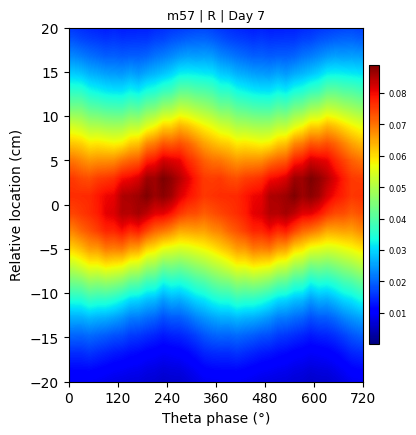

In [47]:
fig, ax = plt.subplots(figsize=(4, 4.6))

plot_relLoc_vs_theta_heatmap(
    theta_cycles_day=m57_R_day7,
    bin_deg=20,
    ylim=(-20, 20),
    cmap="jet",
    title="m57 | R | Day 7",
    ax=ax,
    shift_deg=180
)

plt.show()

## Calculate theta sequence score


In [ ]:
from collections import defaultdict
import os
import glob
import pickle
import numpy as np

mergeDays = {
    "m20": [range(1, 6),  range(6, 11)],
}

def assign_stage(animal, day):
    early_days = mergeDays[animal][0]
    late_days  = mergeDays[animal][1]
    if day in early_days:
        return "early"
    elif day in late_days:
        return "late"
    else:
        return None
    
def _wmean(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    s = np.sum(w)
    return np.sum(w * x) / s if s > 0 else np.nan

def _wcov(x, y, w):
    x = np.asarray(x, float); y = np.asarray(y, float); w = np.asarray(w, float)
    s = np.sum(w)
    if s <= 0:
        return np.nan
    mx = _wmean(x, w); my = _wmean(y, w)
    return np.sum(w * (x - mx) * (y - my)) / s

def _wcorr(x, y, w, eps=1e-12):
    vx = _wcov(x, x, w)
    vy = _wcov(y, y, w)
    if (not np.isfinite(vx)) or (not np.isfinite(vy)) or vx <= eps or vy <= eps:
        return np.nan
    return _wcov(x, y, w) / np.sqrt(vx * vy)

def load_theta_cycles_all_days(save_dir, animal, Env, celltype):
    """
    read file：
      {animal}_{Env}_theta_cycles_{celltype}_spike_and_egf_DayXX.pkl
    """
    pattern = os.path.join(
        save_dir,
        f"{animal}_{Env}_theta_cycles_{celltype}_spike_and_egf_Day*.pkl"
    )
    files = sorted(glob.glob(pattern))
    all_cycles = []
    for fp in files:
        try:
            with open(fp, "rb") as f:
                x = pickle.load(f)
            if isinstance(x, list):
                all_cycles.extend(x)
        except Exception as e:
            print("  ⚠️ load failed:", fp, "reason:", e)

    print(f"Loaded {len(all_cycles)} cycles from {len(files)} day-files for {animal}")
    return all_cycles, files


def wcirc_lin_corr(x, phase_deg, w, eps=1e-12):
    x = np.asarray(x, float)
    ph = np.deg2rad(np.asarray(phase_deg, float))
    w = np.asarray(w, float)

    # drop non-finite / non-positive weights
    m = np.isfinite(x) & np.isfinite(ph) & np.isfinite(w) & (w > 0)
    if np.sum(m) < 5:
        return np.nan
    x = x[m]; ph = ph[m]; w = w[m]

    s = np.sin(ph)
    c = np.cos(ph)

    r_xs = _wcorr(x, s, w, eps=eps)
    r_xc = _wcorr(x, c, w, eps=eps)
    r_sc = _wcorr(s, c, w, eps=eps)

    if not (np.isfinite(r_xs) and np.isfinite(r_xc) and np.isfinite(r_sc)):
        return np.nan

    den = 1.0 - r_sc**2
    if den <= eps:
        return np.nan

    r2 = (r_xs**2 + r_xc**2 - 2.0*r_xs*r_xc*r_sc) / den
    r2 = np.clip(r2, 0.0, 1.0)
    r = np.sqrt(r2)

    # give a sign (one reasonable choice)
    sign = np.sign(_wcov(x, s, w))  # direction proxy
    if sign == 0:
        sign = 1.0
    # return float(sign * r)  # [-1,1]
    return float(r)  #[0,1]

def weighted_corr_phase_s_one_day(cycles_day,
                                 phase_key="phase_deg",
                                 post_key="rel_posterior_1d",
                                 s_key="rel_s_centers"):
    
    if len(cycles_day) == 0:
        return np.nan

    s_centers = np.asarray(cycles_day[0][s_key], float)  # (Ns,)
    Ns = s_centers.size

    S_all, PH_all, W_all = [], [], []

    for cyc in cycles_day:
        animal = cyc.get("animal", None)
        method = cyc.get("method", None)
        day    = cyc.get("day", None)

        ph0 = np.asarray(cyc.get(phase_key, []), float)          # (Nt,)
        P   = np.asarray(cyc.get(post_key,  []), float)          # (Nt,Ns)

        if ph0.size == 0 or P.size == 0:
            continue
        if P.ndim != 2 or P.shape[1] != Ns or P.shape[0] != ph0.size:
            continue

        w = np.nan_to_num(P, nan=0.0, posinf=0.0, neginf=0.0).ravel()
        if np.sum(w) <= 0:
            continue

        s = np.tile(s_centers[None, :], (ph0.size, 1)).ravel()
        y = np.tile(ph0[:, None], (1, Ns)).ravel()

        S_all.append(s)
        PH_all.append(y)
        W_all.append(w)

    if len(W_all) == 0:
        return np.nan

    s = np.concatenate(S_all)
    y = np.concatenate(PH_all)
    w = np.concatenate(W_all)

    # return float(_wcorr(s, y, w)) #linear correlation

    return float(wcirc_lin_corr(s, y, w)) #circular correlation

def compute_daily_weighted_corr(cycles_method,
                                phase_key="phase_deg",
                                min_cycles_per_day=20):
    groups = defaultdict(list)
    for c in cycles_method:
        animal = c.get("animal", None)
        day = c.get("day", None)
        if animal is None or day is None:
            continue
        groups[(animal, int(day))].append(c)

    records = []
    for (animal, day), cc in sorted(groups.items(), key=lambda kv: (kv[0][0], kv[0][1])):
        if len(cc) < min_cycles_per_day:
            continue

        # stage majority
        st = [x.get("stage", None) for x in cc if x.get("stage", None) is not None]
        stage = None
        if len(st) > 0:
            uniq, cnt = np.unique(np.asarray(st, object), return_counts=True)
            stage = str(uniq[np.argmax(cnt)])

        method = cc[0].get("method", "unknown")
        r_w = weighted_corr_phase_s_one_day(cc, phase_key=phase_key)

        records.append({
            "animal": animal,
            "day": day,
            "stage": stage,
            "method": method,
            "r_w": r_w,
            "n_cycles": len(cc)
        })

    return records

def records_to_table(records, value_key="r_w"):
    rows = []
    for r in records:
        rows.append({
            "Animal": r.get("animal", None),
            "Day": int(r.get("day", -1)) if r.get("day", None) is not None else None,
            "Stage": r.get("stage", None),
            "WeightedCorr": r.get(value_key, np.nan),
        })
    df = pd.DataFrame(rows)
    if len(df) > 0:
        df = df.sort_values(["Animal", "Day"], kind="mergesort").reset_index(drop=True)
    return df

def save_weightedcorr_tables_csv(rec_spk, rec_egf, out_dir, basename="daily_weighted_corr"):
    os.makedirs(out_dir, exist_ok=True)

    df_spk = records_to_table(rec_spk)
    df_egf = records_to_table(rec_egf)

    # 分开保存
    spk_path = os.path.join(out_dir, f"{basename}_spike.csv")
    egf_path = os.path.join(out_dir, f"{basename}_egf.csv")
    df_spk.to_csv(spk_path, index=False)
    df_egf.to_csv(egf_path, index=False)

    df_all = pd.concat([df_spk.assign(Method="spike"),
                        df_egf.assign(Method="egf")], ignore_index=True)
    all_path = os.path.join(out_dir, f"{basename}_all.csv")
    df_all.to_csv(all_path, index=False)

    print("✅ Saved CSV:", spk_path)
    print("✅ Saved CSV:", egf_path)
    print("✅ Saved CSV:", all_path)

In [ ]:
# Calculate theta-sequence circular correlation
import pandas as pd

SAVE_DIR = r"C:\VRresults"
Env = "VR"
celltype = "CA1MEC"

WHICH = "all"          # "all" or a single animal, e.g. "m20"
MIN_CYCLES_PER_DAY = 20

animals = sorted(mergeDays) if WHICH == "all" else [WHICH]
all_cycles = {"spike": [], "egf": []}

# Load cycles from all selected animals
for animal in animals:
    print(f"\nProcessing {animal}")

    theta_cycles_all, _ = load_theta_cycles_all_days(SAVE_DIR, animal, Env, celltype)

    if not theta_cycles_all:
        print(f"{animal}: no cycles loaded, skip.")
        continue

    for c in theta_cycles_all:
        c["stage"] = assign_stage(animal, int(c.get("day", -1)))

        method = c.get("method")
        if method in all_cycles and c.get("animal") == animal:
            all_cycles[method].append(c)

# Calculate daily posterior-weighted circular correlations
records = {}

for method in ["spike", "egf"]:
    records[method] = compute_daily_weighted_corr(
        all_cycles[method],
        phase_key="phase_deg",
        min_cycles_per_day=MIN_CYCLES_PER_DAY
    )

# Save results
OUT_DIR = os.path.join(
    SAVE_DIR,
    "ThetaPhaseWeightedCorr_circularCorre",
    f"{Env}-{celltype}"
)

os.makedirs(OUT_DIR, exist_ok=True)

save_weightedcorr_tables_csv(
    records["spike"],
    records["egf"],
    OUT_DIR,
    basename=f"{Env}_{celltype}_weightedCorr"
)

print("Weighted-correlation results saved to:", OUT_DIR)